# Multimodal Deepfake Detection — Exploratory Data Analysis

This notebook covers:
1. Dataset statistics and class distribution
2. Frame quality analysis
3. Audio feature visualisation
4. Model prediction analysis
5. Grad-CAM explainability demos

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import cv2
import librosa
import librosa.display
import torch
from pathlib import Path
from IPython.display import display, HTML

%matplotlib inline
plt.style.use('dark_background')
print('Setup complete')

Setup complete


## 1. Dataset Statistics

In [2]:
from data.preprocess import print_dataset_stats
DATA_DIR = Path('../../dock/processed/video')   # update to your path
print_dataset_stats(DATA_DIR)

2026-05-12 20:23:28.453 | INFO     | data.preprocess:print_dataset_stats:315 -   real: 15318 files
2026-05-12 20:23:28.516 | INFO     | data.preprocess:print_dataset_stats:320 -     Size: min=22.7KB  mean=28.8KB  max=38.1KB
2026-05-12 20:23:37.453 | INFO     | data.preprocess:print_dataset_stats:315 -   fake: 283976 files
2026-05-12 20:23:37.504 | INFO     | data.preprocess:print_dataset_stats:320 -     Size: min=22.1KB  mean=26.0KB  max=29.5KB


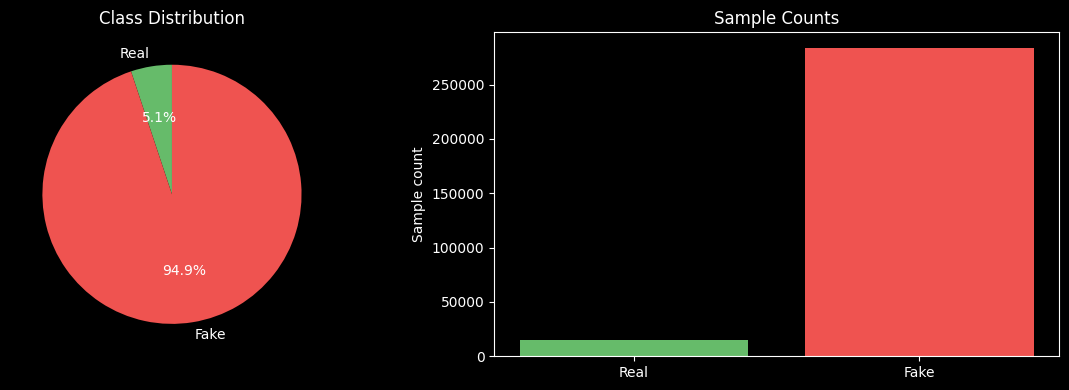

Real: 15318  |  Fake: 283976  |  Total: 299294


In [3]:
# Class distribution pie chart
from pathlib import Path

real_count = len(list((DATA_DIR / 'real').glob('*.jpg')))
fake_count = len(list((DATA_DIR / 'fake').glob('*.jpg')))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie([real_count, fake_count], labels=['Real', 'Fake'],
            colors=['#66bb6a', '#ef5350'], autopct='%1.1f%%',
            startangle=90)
axes[0].set_title('Class Distribution')

axes[1].bar(['Real', 'Fake'], [real_count, fake_count],
            color=['#66bb6a', '#ef5350'])
axes[1].set_ylabel('Sample count')
axes[1].set_title('Sample Counts')

plt.tight_layout()
plt.show()
print(f'Real: {real_count}  |  Fake: {fake_count}  |  Total: {real_count+fake_count}')

## 2. Frame Quality Analysis

d:\COLLEGE\SEM6\MinorProjectII\deepfake_detector\.venv\Lib\site-packages\ctranslate2\__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
d:\COLLEGE\SEM6\MinorProjectII\deepfake_detector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-12 20:23:45.408 | INFO     | backend.utils.extraction:extract_frames:43 - Video: 129 frames @ 25.0 fps
2026-05-12 20:23:45.460 | INFO     | backend.utils.extraction:extract_frames:59 - Extracted 2 frames from 00001.mp4
2026-05-12 20:23:45.473 | INFO     | backend.utils.extraction:extract_frames:43 - Video: 129 frames @ 25.0 fps
2026-05-12 20:23:45

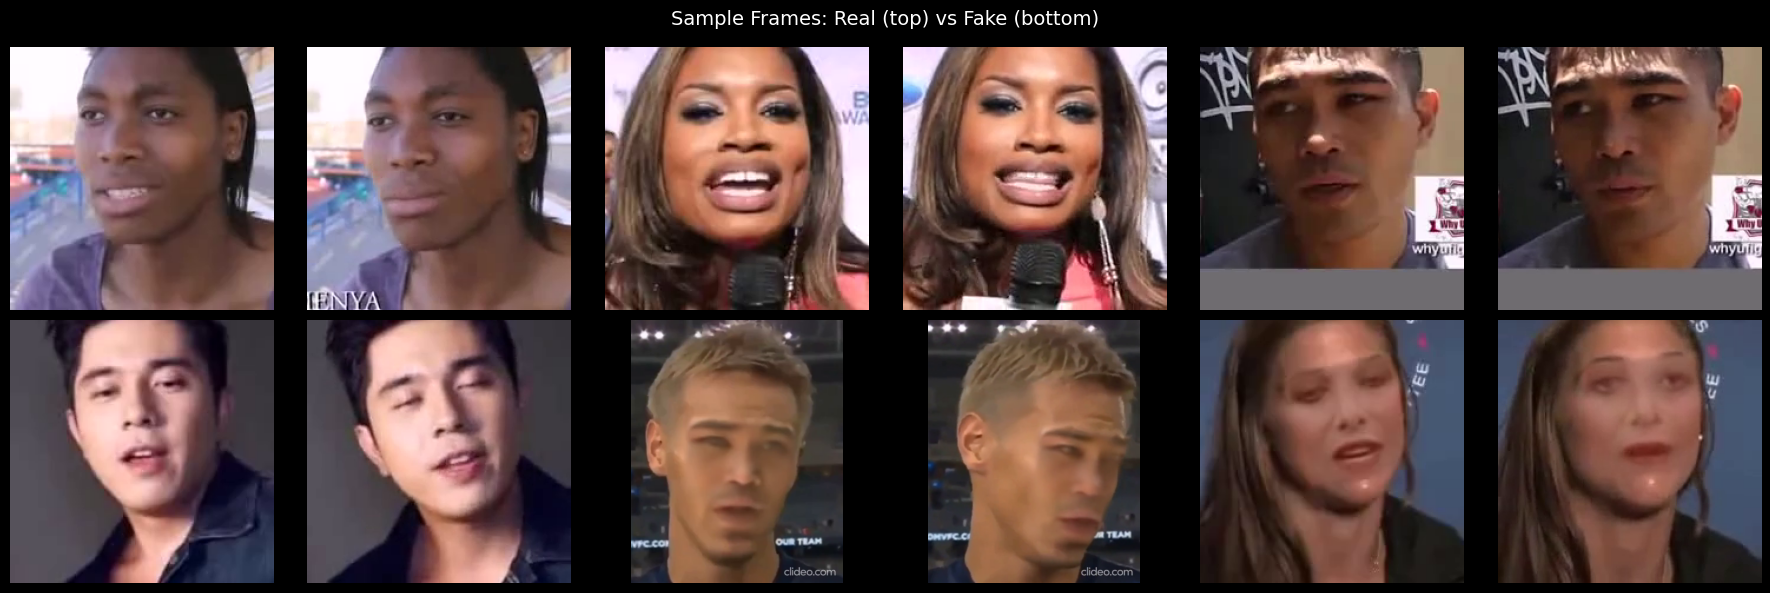

In [4]:
from backend.utils.extraction import extract_frames

# Show sample frames from real vs fake
SAMPLE_REAL = list(DATA_DIR.glob('../../raw/video/real/*.mp4'))[:3]  # adjust
SAMPLE_FAKE = list(DATA_DIR.glob('../../raw/video/fake/*.mp4'))[:3]  # adjust

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Frames: Real (top) vs Fake (bottom)', fontsize=14)

for col, (real_vid, fake_vid) in enumerate(zip(SAMPLE_REAL, SAMPLE_FAKE)):
    r_frames = extract_frames(real_vid, sample_rate=30, max_frames=2)
    f_frames = extract_frames(fake_vid, sample_rate=30, max_frames=2)
    for i, frame in enumerate(r_frames[:2]):
        axes[0][col*2+i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[0][col*2+i].axis('off')
    for i, frame in enumerate(f_frames[:2]):
        axes[1][col*2+i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[1][col*2+i].axis('off')

plt.tight_layout()
plt.show()

## 3. Audio Feature Visualisation

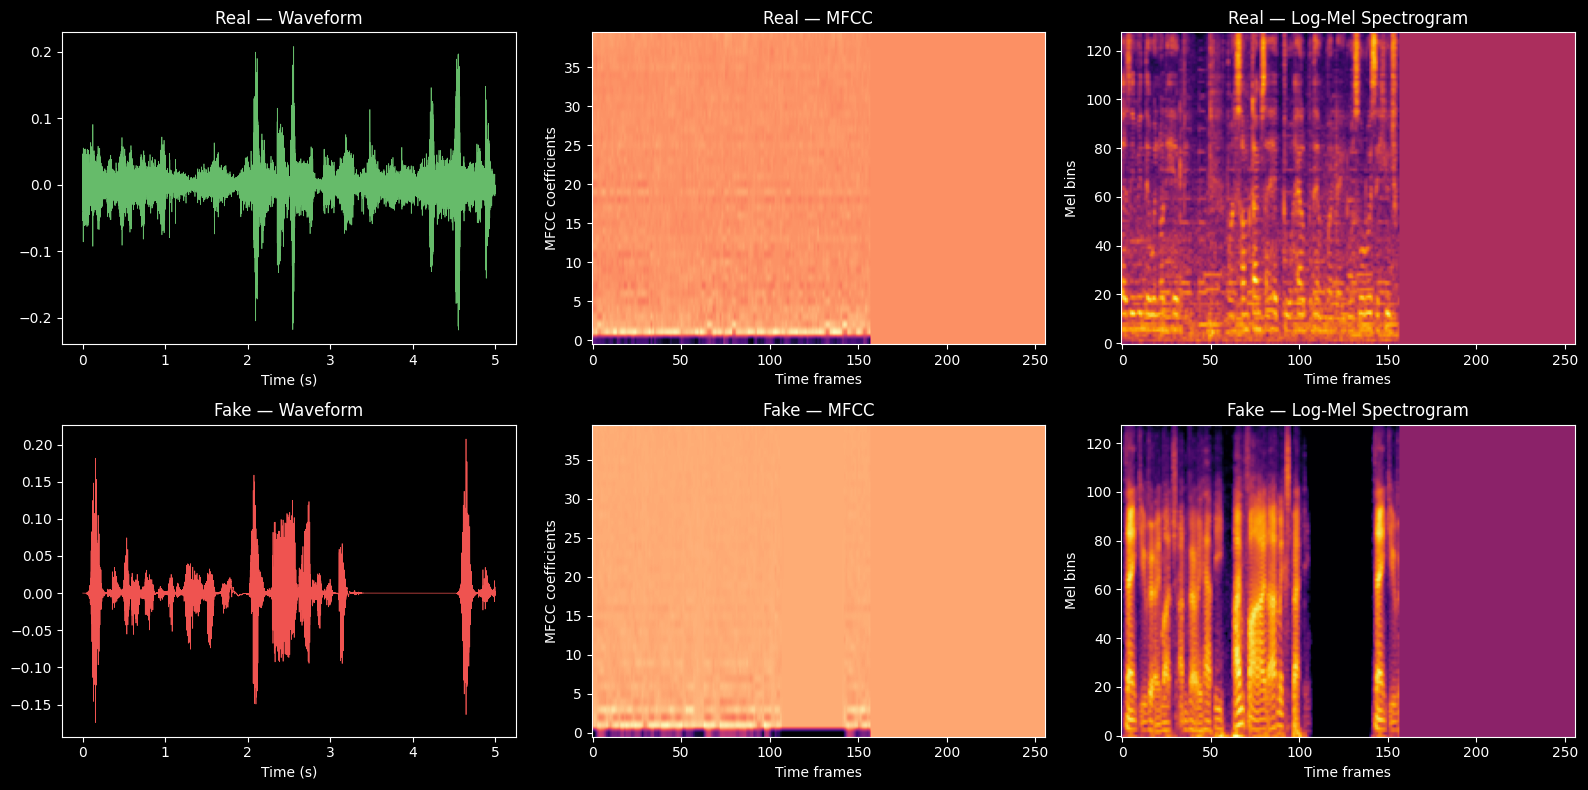

In [5]:
from backend.utils.extraction import extract_audio, compute_mfcc, compute_mel_spectrogram

REAL_WAV = list((DATA_DIR / '../../processed/audio/real').glob('*.wav'))[0]
FAKE_WAV = list((DATA_DIR / '../../processed/audio/fake').glob('*.wav'))[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (wav_path, label) in enumerate([(REAL_WAV, 'Real'), (FAKE_WAV, 'Fake')]):
    waveform, sr = librosa.load(str(wav_path), sr=16000, duration=5.0)
    mfcc = compute_mfcc(waveform, sr)
    mel  = compute_mel_spectrogram(waveform, sr)

    # Waveform
    t = np.linspace(0, len(waveform)/sr, len(waveform))
    axes[row][0].plot(t, waveform, lw=0.5, color='#66bb6a' if row==0 else '#ef5350')
    axes[row][0].set_title(f'{label} — Waveform')
    axes[row][0].set_xlabel('Time (s)')

    # MFCC
    axes[row][1].imshow(mfcc, aspect='auto', origin='lower', cmap='magma')
    axes[row][1].set_title(f'{label} — MFCC')
    axes[row][1].set_xlabel('Time frames')
    axes[row][1].set_ylabel('MFCC coefficients')

    # Mel spectrogram
    axes[row][2].imshow(mel, aspect='auto', origin='lower', cmap='inferno')
    axes[row][2].set_title(f'{label} — Log-Mel Spectrogram')
    axes[row][2].set_xlabel('Time frames')
    axes[row][2].set_ylabel('Mel bins')

plt.tight_layout()
plt.show()

## 4. Quick Inference Demo

In [6]:
from backend.inference_pipeline import InferencePipeline

pipeline = InferencePipeline()
TEST_VIDEO = '../../dock/raw/video/real/00001_1.mp4'   # put your test video here
result = pipeline.run(TEST_VIDEO)

print(f'Label:       {result.label}')
print(f'Fake prob:   {result.fake_probability:.2%}')
print(f'Confidence:  {result.confidence}')
print(f'Video score: {result.video_score:.2%}')
print(f'Audio score: {result.audio_score:.2%}')
print(f'Text score:  {result.text_score:.2%}')
print(f'Time:        {result.processing_time_s}s')
print('\nExplanation:')
for line in result.explanation:
    print(' ·', line)

2026-05-12 20:24:06.738 | INFO     | backend.inference_pipeline:__init__:75 - Initialising pipeline on device: cuda
2026-05-12 20:24:08.861 | INFO     | models.video.video_model:__init__:187 - Video model loaded from D:\COLLEGE\SEM6\MinorProjectII\deepfake_detector\data\models\video_model.pth
2026-05-12 20:24:09.178 | INFO     | models.audio.audio_model:__init__:184 - Audio model loaded from D:\COLLEGE\SEM6\MinorProjectII\deepfake_detector\data\models\audio_model.pth
2026-05-12 20:24:11.819 | WARNING  | models.text.text_model:__init__:162 - No trained text weights - using random init (for demo)
2026-05-12 20:24:11.913 | INFO     | models.fusion.fusion:__init__:158 - Fusion strategy: weighted
2026-05-12 20:24:11.916 | SUCCESS  | backend.inference_pipeline:__init__:84 - Pipeline ready
2026-05-12 20:24:11.960 | INFO     | backend.inference_pipeline:_run_pipeline:115 - Video metadata: {'fps': 25.0, 'frame_count': 104, 'width': 224, 'height': 224, 'duration_s': 4.16}
2026-05-12 20:24:11.962

Label:       REAL
Fake prob:   2.70%
Confidence:  HIGH
Video score: 0.07%
Audio score: 0.05%
Text score:  19.30%
Time:        12.71s

Explanation:
 · Final score: 2.70% → REAL (HIGH confidence)
 · Video appears authentic (score=0.00)
 · Audio appears to be genuine voice (score=0.00)
 · Lip-sync appears consistent (score=0.00)


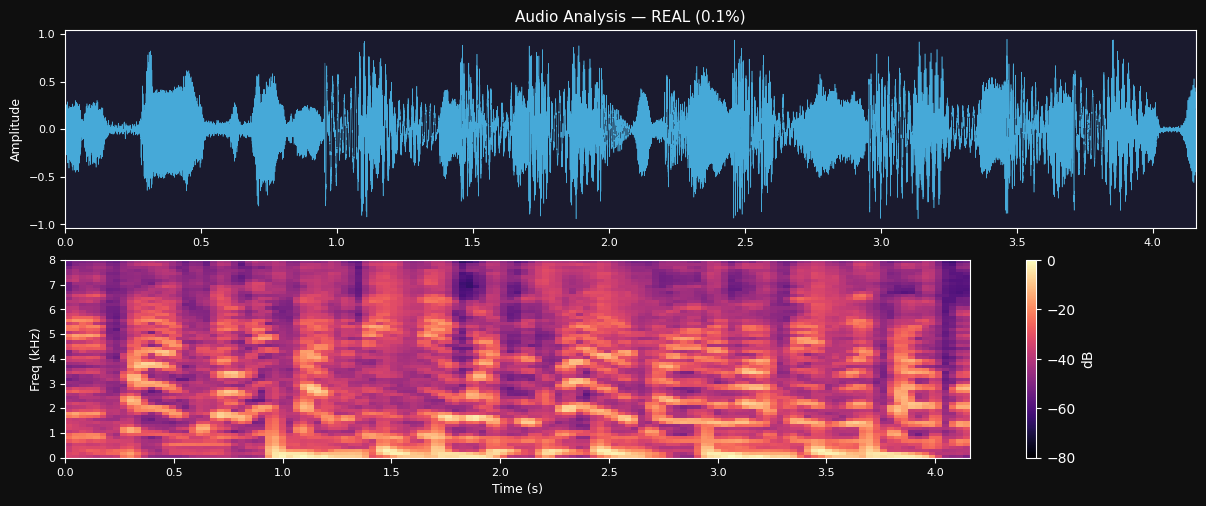

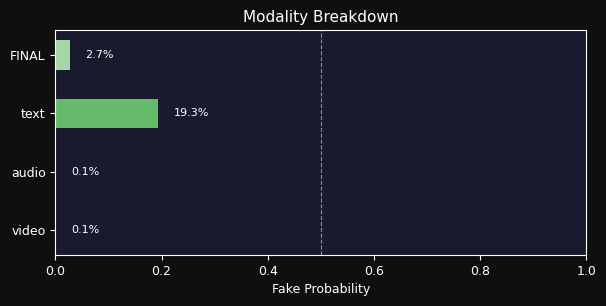

In [7]:
# Display audio analysis plot
import base64
from IPython.display import Image

if result.audio_plot:
    display(Image(data=base64.b64decode(result.audio_plot)))

if result.breakdown_plot:
    display(Image(data=base64.b64decode(result.breakdown_plot)))

## 5. Evaluation Results

In [8]:
from training.evaluate import evaluate_pipeline
from models.video.video_model import VideoInference
from models.audio.audio_model import AudioInference

video_model = VideoInference(Path('../data/models/video_model.pth'), 'cpu')
audio_model = AudioInference(Path('../data/models/audio_model.pth'), 'cpu')

test_dir = Path('../../dock/test/tog')
test_videos = []
for label, cls in [(0, 'real'), (1, 'fake')]:
    test_videos += [(p, label) for p in (test_dir / cls).glob('*.mp4')]

metrics = evaluate_pipeline(
    test_videos[:],   # limit to 50 for demo speed
    video_model, audio_model,
    Path('../eval_results/')
)

for k, v in metrics.items():
    print(f'{k:<20} {v}')

2026-05-12 20:24:26.324 | INFO     | models.video.video_model:__init__:187 - Video model loaded from ..\data\models\video_model.pth
2026-05-12 20:24:26.473 | INFO     | models.audio.audio_model:__init__:184 - Audio model loaded from ..\data\models\audio_model.pth
2026-05-12 20:24:26.488 | INFO     | models.fusion.fusion:__init__:158 - Fusion strategy: weighted
Evaluating:   0%|          | 0/130 [00:00<?, ?it/s]2026-05-12 20:24:26.515 | INFO     | backend.utils.extraction:extract_frames:43 - Video: 156 frames @ 25.0 fps
2026-05-12 20:24:26.636 | INFO     | backend.utils.extraction:extract_frames:59 - Extracted 16 frames from 002121.mp4
2026-05-12 20:24:26.915 | INFO     | backend.utils.extraction:extract_audio:118 - Audio extracted: 6.3s @ 16000 Hz
2026-05-12 20:24:30.010 | INFO     | models.fusion.fusion:fuse:69 - Fusion using: ['video', 'audio']
Evaluating:   1%|          | 1/130 [00:03<07:33,  3.51s/it]2026-05-12 20:24:30.029 | INFO     | backend.utils.extraction:extract_frames:43 - 

n_samples            130
n_errors             0
accuracy             0.9538
precision            0.9275
recall               0.9846
f1                   0.9552
auc_roc              0.9867
avg_precision        0.9777


In [9]:
# Display saved evaluation plots
from IPython.display import display
import matplotlib.image as mpimg

eval_plots = ['confusion_matrix.png', 'roc_curve.png', 
              'pr_curve.png', 'threshold_analysis.png']

fig, axes = plt.subplots(1, len(eval_plots), figsize=(20, 5))
for ax, name in zip(axes, eval_plots):
    path = Path(f'../eval_results/{name}')
    if path.exists():
        ax.imshow(mpimg.imread(path))
    ax.axis('off')
plt.tight_layout()
plt.show()

C:\Users\Ashish Chandra\AppData\Local\Temp\ipykernel_26984\4145972629.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


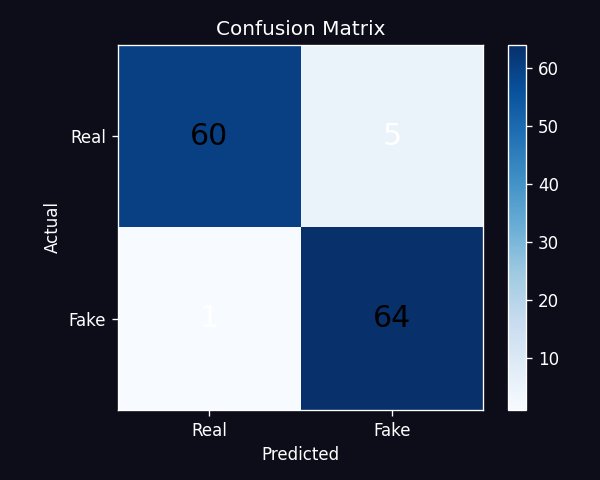

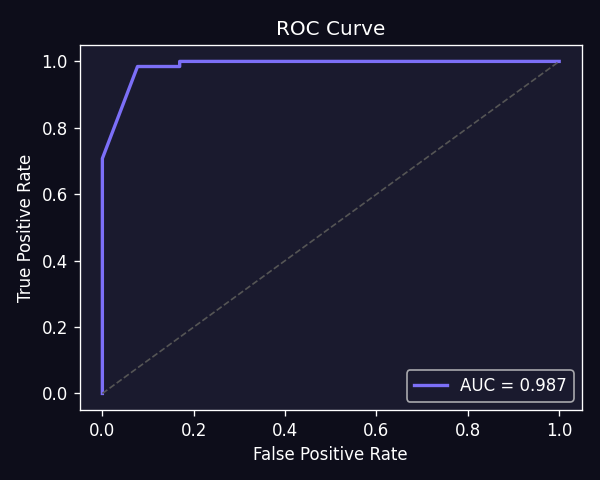

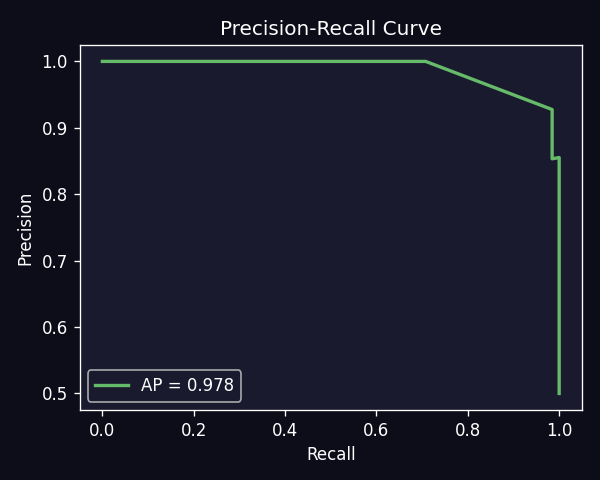

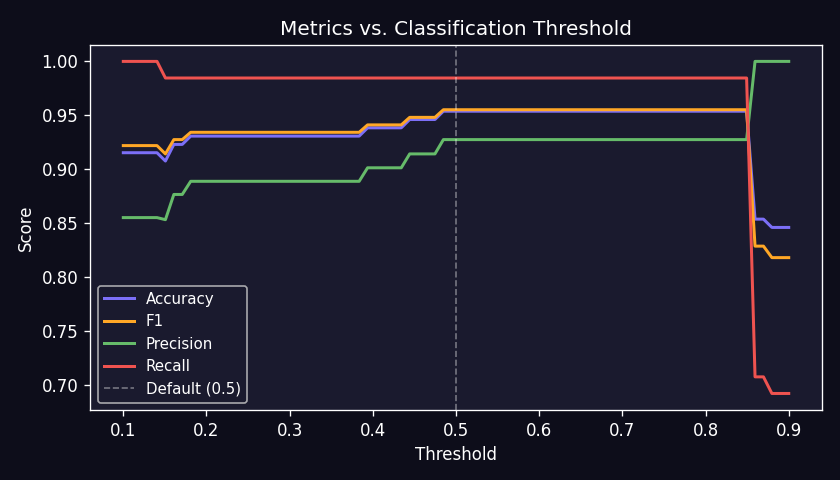

In [10]:
from IPython.display import Image, display
from pathlib import Path

eval_plots = ['confusion_matrix.png', 'roc_curve.png', 
              'pr_curve.png', 'threshold_analysis.png']

for name in eval_plots:
    path = Path(f'../eval_results/{name}')
    if path.exists():
        display(Image(filename=str(path)))

In [11]:
from training.evaluate import evaluate_video_model
from models.video.video_model import VideoInference
# from models.audio.audio_model import AudioInference

video_model = VideoInference(Path('../data/models/video_model.pth'), 'cpu')
# audio_model = AudioInference(Path('../data/models/audio_model.pth'), 'cpu')

test_dir = Path('../../dock/test/video')
test_videos = []
for label, cls in [(0, 'real'), (1, 'fake')]:
    test_videos += [(p, label) for p in (test_dir / cls).glob('*.mp4')]

metrics = evaluate_video_model(
    test_videos[:],   # limit to 50 for demo speed
    video_model, #audio_model,
    Path('../eval_results/')
)

for k, v in metrics.items():
    print(f'{k:<20} {v}')

2026-05-12 20:32:25.612 | INFO     | models.video.video_model:__init__:187 - Video model loaded from ..\data\models\video_model.pth
Evaluating Video:   0%|          | 0/130 [00:00<?, ?it/s]2026-05-12 20:32:25.663 | INFO     | backend.utils.extraction:extract_frames:43 - Video: 156 frames @ 25.0 fps
2026-05-12 20:32:25.892 | INFO     | backend.utils.extraction:extract_frames:59 - Extracted 16 frames from 002121.mp4
Evaluating Video:   1%|          | 1/130 [00:02<05:33,  2.59s/it]2026-05-12 20:32:28.255 | INFO     | backend.utils.extraction:extract_frames:43 - Video: 151 frames @ 24.0 fps
2026-05-12 20:32:28.388 | INFO     | backend.utils.extraction:extract_frames:59 - Extracted 16 frames from 002121_fake.mp4
Evaluating Video:   2%|▏         | 2/130 [00:05<05:32,  2.60s/it]2026-05-12 20:32:30.864 | INFO     | backend.utils.extraction:extract_frames:43 - Video: 151 frames @ 25.0 fps
2026-05-12 20:32:30.944 | INFO     | backend.utils.extraction:extract_frames:59 - Extracted 16 frames from 

n_samples            130
n_errors             0
accuracy             0.9077
precision            0.863
recall               0.9692
f1                   0.913
auc_roc              0.9613
avg_precision        0.9362


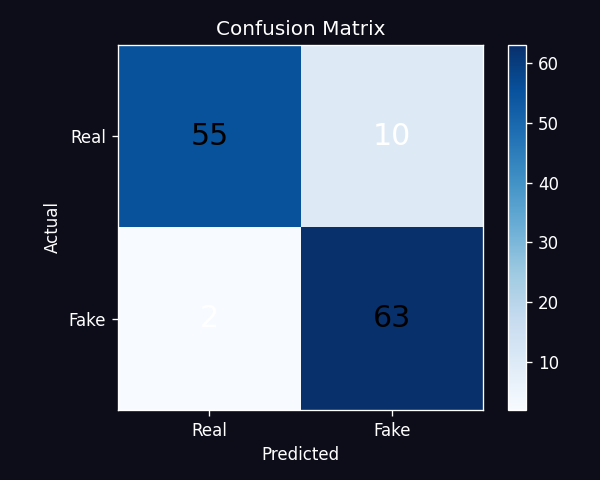

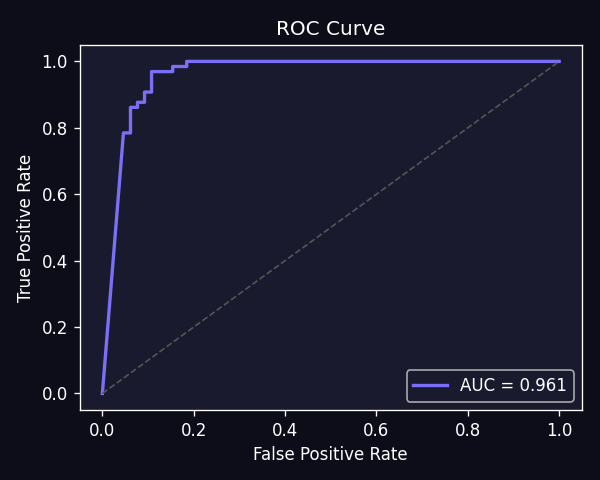

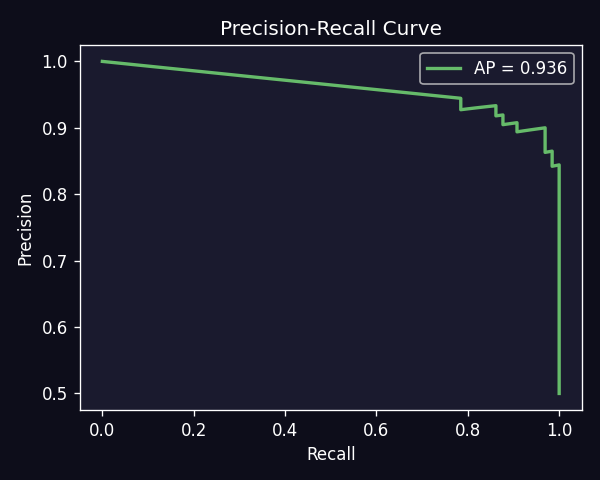

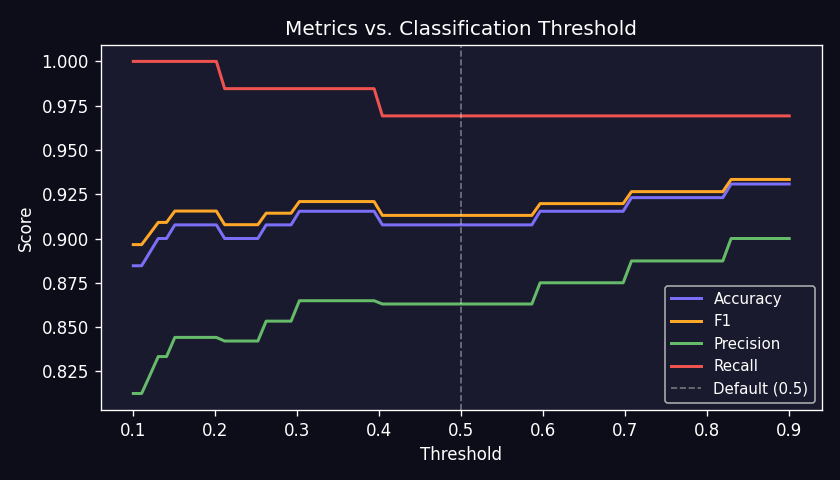

In [12]:
from IPython.display import Image, display
from pathlib import Path

eval_plots = ['video_confusion_matrix.png', 'video_roc_curve.png', 
              'video_pr_curve.png', 'video_threshold_analysis.png']

for name in eval_plots:
    path = Path(f'../eval_results/{name}')
    if path.exists():
        display(Image(filename=str(path)))

In [13]:
from training.evaluate import evaluate_audio_model
# from models.video.video_model import VideoInference
from models.audio.audio_model import AudioInference

# video_model = VideoInference(Path('../data/models/video_model.pth'), 'cpu')
audio_model = AudioInference(Path('../data/models/audio_model.pth'), 'cpu')

test_dir = Path('../../dock/test/audio')
test_videos = []
for label, cls in [(0, 'real'), (1, 'fake')]:
    test_videos += [(p, label) for p in (test_dir / cls).glob('*.mp4')]

metrics = evaluate_audio_model(
    test_videos[:],   # limit to 50 for demo speed
    # video_model, 
    audio_model,
    Path('../eval_results/')
)

for k, v in metrics.items():
    print(f'{k:<20} {v}')

2026-05-12 20:39:21.693 | INFO     | models.audio.audio_model:__init__:184 - Audio model loaded from ..\data\models\audio_model.pth
Evaluating Audio: 100%|██████████| 130/130 [00:42<00:00,  3.03it/s]
2026-05-12 20:40:04.694 | INFO     | training.evaluate:evaluate_audio_model:224 - [AUDIO] Metrics: {
  "n_samples": 130,
  "n_errors": 0,
  "accuracy": 0.9846,
  "precision": 0.9846,
  "recall": 0.9846,
  "f1": 0.9846,
  "auc_roc": 0.9998,
  "avg_precision": 0.9998
}
2026-05-12 20:40:05.021 | INFO     | training.evaluate:_plot_confusion_matrix:266 - Saved confusion_matrix.png
2026-05-12 20:40:05.380 | INFO     | training.evaluate:_plot_roc_curve:289 - Saved roc_curve.png
2026-05-12 20:40:07.997 | INFO     | training.evaluate:_plot_threshold_analysis:364 - Saved threshold_analysis.png


n_samples            130
n_errors             0
accuracy             0.9846
precision            0.9846
recall               0.9846
f1                   0.9846
auc_roc              0.9998
avg_precision        0.9998


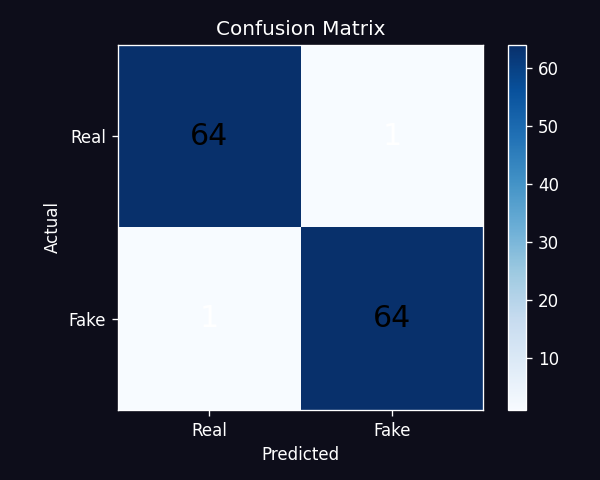

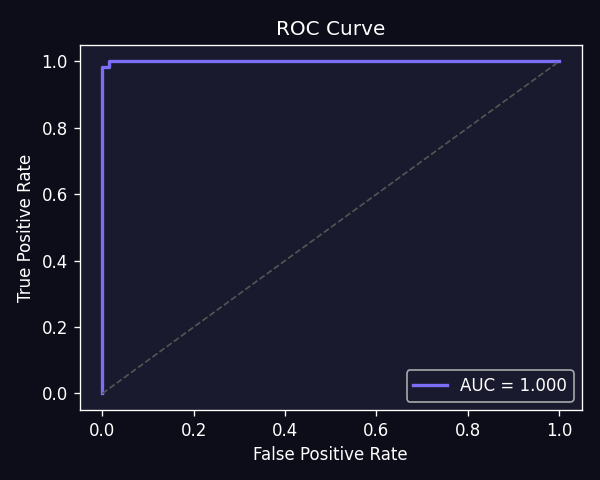

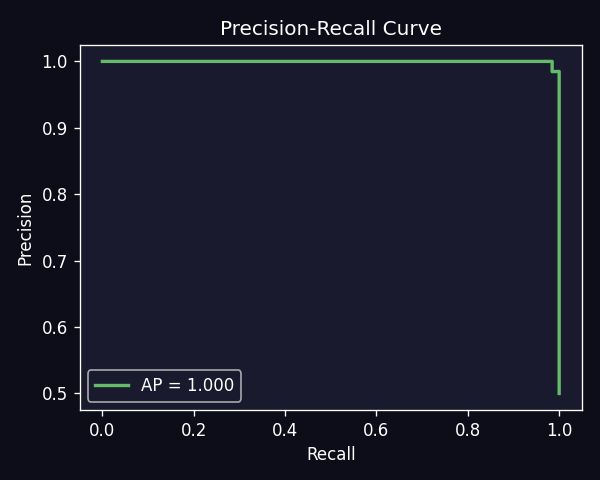

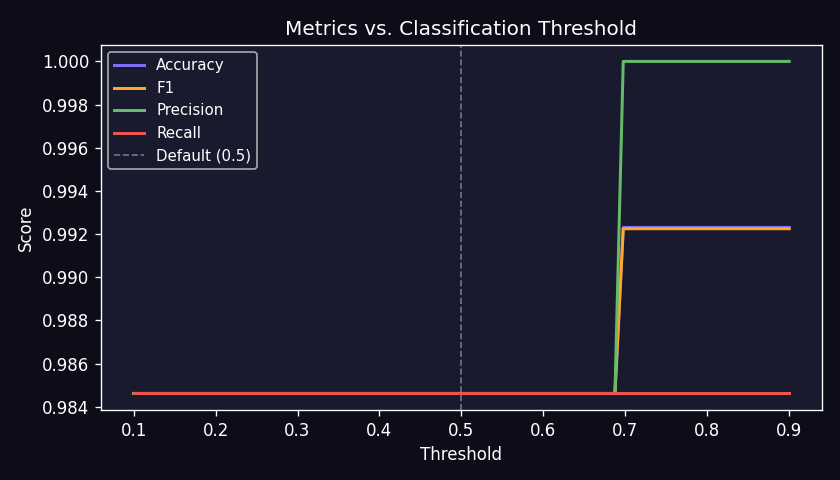

In [14]:
from IPython.display import Image, display
from pathlib import Path

eval_plots = ['audio_confusion_matrix.png', 'audio_roc_curve.png', 
              'audio_pr_curve.png', 'audio_threshold_analysis.png']

for name in eval_plots:
    path = Path(f'../eval_results/{name}')
    if path.exists():
        display(Image(filename=str(path)))